# Momentum

## Plain gradient descent (baseline)
$$w_{t+1} = w_t - \eta\, \nabla L(w_t)$$
Depends only on the *current* gradient — no memory. This causes zigzagging in narrow valleys.

## Momentum: add a velocity term
$$v_{t+1} = \beta\, v_t + \nabla L(w_t)$$
$$w_{t+1} = w_t - \eta\, v_{t+1}$$

- **v** = velocity: a running (exponentially-weighted) average of past gradients.
- **β** = momentum coefficient (≈0.9). β=0 recovers plain GD.

## Why it kills the zigzag
Unrolling the velocity:
$$v_{t+1} = \nabla L(w_t) + \beta\nabla L(w_{t-1}) + \beta^2\nabla L(w_{t-2}) + \dots$$

This is an **exponential moving average** of gradients:
- **Oscillating directions** (alternating sign, +,−,+,−) → terms **cancel** → wobble shrinks.
- **Consistent directions** (same sign) → terms **add up** → amplified by **1/(1−β)**
  (with β=0.9, that's a **10× speed-up** along the valley).

Effective learning rate along consistent directions: η/(1−β).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Narrow valley: steep in w2, gentle in w1
def loss(w): return w[0]**2 + 20*w[1]**2
def grad(w): return np.array([2*w[0], 40*w[1]])

start = np.array([9.0, 1.0]); steps = 60

def plain_gd(eta):
    w = start.copy(); path=[w.copy()]
    for _ in range(steps):
        w = w - eta*grad(w); path.append(w.copy())
    return np.array(path)

def momentum_gd(eta, beta=0.9):
    w = start.copy(); v = np.zeros(2); path=[w.copy()]
    for _ in range(steps):
        v = beta*v + grad(w)      # velocity = EMA of gradients
        w = w - eta*v             # step using velocity, not raw gradient
        path.append(w.copy())
    return np.array(path)

eta_plain = 0.048   # near steep-direction limit -> plain GD zigzags
eta_mom   = 0.008   # smaller, because momentum amplifies by 1/(1-beta)=10x
p_plain = plain_gd(eta_plain)
p_mom   = momentum_gd(eta_mom, beta=0.9)

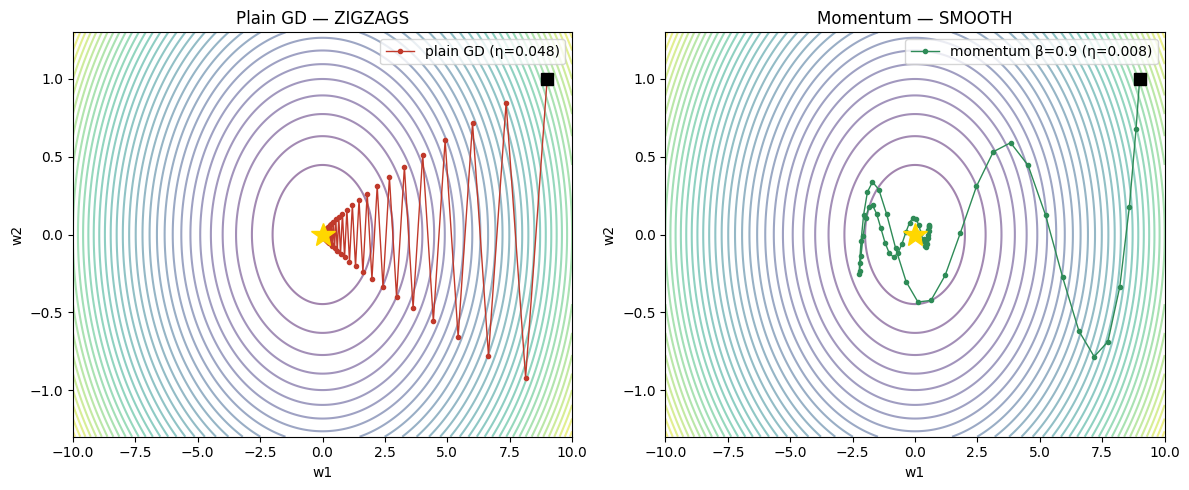

In [2]:
w1 = np.linspace(-10, 10, 400); w2 = np.linspace(-1.3, 1.3, 400)
W1, W2 = np.meshgrid(w1, w2); Z = W1**2 + 20*W2**2

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contour(W1, W2, Z, levels=35, cmap='viridis', alpha=0.5)
plt.plot(p_plain[:,0], p_plain[:,1], 'o-', color='#c0392b', markersize=3, linewidth=1, label=f'plain GD (η={eta_plain})')
plt.plot(0,0,'*',color='gold',markersize=18); plt.plot(*start,'s',color='k',markersize=8)
plt.title('Plain GD — ZIGZAGS'); plt.xlabel('w1'); plt.ylabel('w2'); plt.legend(loc='upper right')

plt.subplot(1,2,2)
plt.contour(W1, W2, Z, levels=35, cmap='viridis', alpha=0.5)
plt.plot(p_mom[:,0], p_mom[:,1], 'o-', color='#2e8b57', markersize=3, linewidth=1, label=f'momentum β=0.9 (η={eta_mom})')
plt.plot(0,0,'*',color='gold',markersize=18); plt.plot(*start,'s',color='k',markersize=8)
plt.title('Momentum — SMOOTH'); plt.xlabel('w1'); plt.ylabel('w2'); plt.legend(loc='upper right')
plt.tight_layout(); plt.show()

In [3]:
def sign_flips(path):
    s = np.sign(path[:,1]); return int(np.sum(s[1:]!=s[:-1]))
print(f"Plain GD : w2 sign-flips = {sign_flips(p_plain)}  (zigzag)")
print(f"Momentum : w2 sign-flips = {sign_flips(p_mom)}  (much smoother)")

Plain GD : w2 sign-flips = 60  (zigzag)
Momentum : w2 sign-flips = 11  (much smoother)


## What this shows
- **Plain GD** flips w2's sign ~every step (60 flips) — a jagged sawtooth across the valley.
- **Momentum** flips far less (~11) — a smooth roll toward the minimum.

The velocity (EMA of gradients) **cancels the oscillating w2 component** and **accumulates
the consistent w1 direction**. Result: less wobble, faster real progress.
